<a href="https://colab.research.google.com/github/catebarry/explainable-techniques-2/blob/main/explainable_techniques_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIPI 590 - XAI | Assignment 3: Explainable Techniques II
### Catie Barry

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/catebarry/explainable-techniques-2/blob/main/explainable_techniques_2.ipynb)

# Description
We will be exploring a medical insurance cost dataset from Kaggle. We will first conduct an exploratory analysis to determine the amount of correlation between features. Then, we will analyze interesting findings from PDP, ICE, and ALE plots.

**SOURCES:**
- Inspiration from Dr. Brinnae Bent's [Duke-AI-XAI repo](https://github.com/AIPI-590-XAI/Duke-AI-XAI/blob/main/explainable-ml-example-notebooks/global_explanations.ipynb) about global explanations
- [Medical insurance cost dataset](https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset) from Kaggle
- Limited use of ChatGPT 5.0 for this assignment, but specific citations noted throughout within comments

In [5]:
# Please use this to connect your GitHub repository to your Google Colab notebook
# Connects to any needed files from GitHub and Google Drive
import os

# Remove Colab default sample_data
!rm -r ./sample_data

# Clone GitHub files to colab workspace
repo_name = "explainable-techniques-2" # Change to your repo name
git_path = 'https://github.com/catebarry/explainable-techniques-2.git' #Change to your path
!git clone "{git_path}"

# Install dependencies from requirements.txt file
#!pip install -r "{os.path.join(repo_name,'requirements.txt')}" #Add if using requirements.txt

# Change working directory to location of notebook
notebook_dir = ''
path_to_notebook = os.path.join(repo_name,notebook_dir)
%cd "{path_to_notebook}"
%ls

rm: cannot remove './sample_data': No such file or directory
fatal: destination path 'explainable-techniques-2' already exists and is not an empty directory.
/content/explainable-techniques-2
explainable_techniques_2.ipynb  insurance.csv  README.md


In [50]:
# installations
!pip install numpy==1.25.2 pandas==2.0.3 scikit-learn==1.2.2 shap==0.45.1
!pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

  Using cached numpy-1.25.2.tar.gz (10.8 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Cloning https://github.com/MaximeJumelle/ALEPython.git (to revision dev) to /tmp/pip-install-a23px3zq/alepython_f17014694973473dbdf925923f4ad083
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-a23px3zq/alepython_f17014694973473dbdf925923f4ad083
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab67

In [9]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split

import shap
from alepython import ale_plot
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

np.random.seed(1)

# Exploratory Data Analysis 🔍
### Load & Inspect Dataset

**Dataset:** We will use a medical insurance cost dataset, which includes information from 1338 people. This is a regression task to predict insurance costs for individuals (numeric target variable 'charges') based on demographic and health-related features.
- Categorical features include sex, smoking status, and US residential region.
- Numerical features include age, BMI, and number of children.

**Model:** We will train an XGBoost regressor model with default parameters for explanatory purposes. We are performing a 70-30 train/test split to provide enough data for training while setting aside a substantial portion for evaluation.

In [11]:
# load dataset
df = pd.read_csv("insurance.csv")

# inspect
print(df.head())
print(df.info())
print(df.describe())
df.isnull().sum()

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


No missing values. Categorical and numerical data types as expected.

### Numerical Distributions
- Age fairly uniform from 18 to 64 (with spike around 20)
- BMI centered around 30
- Most with 0-2 children, few with 4 or 5
- Charges highly skewed right

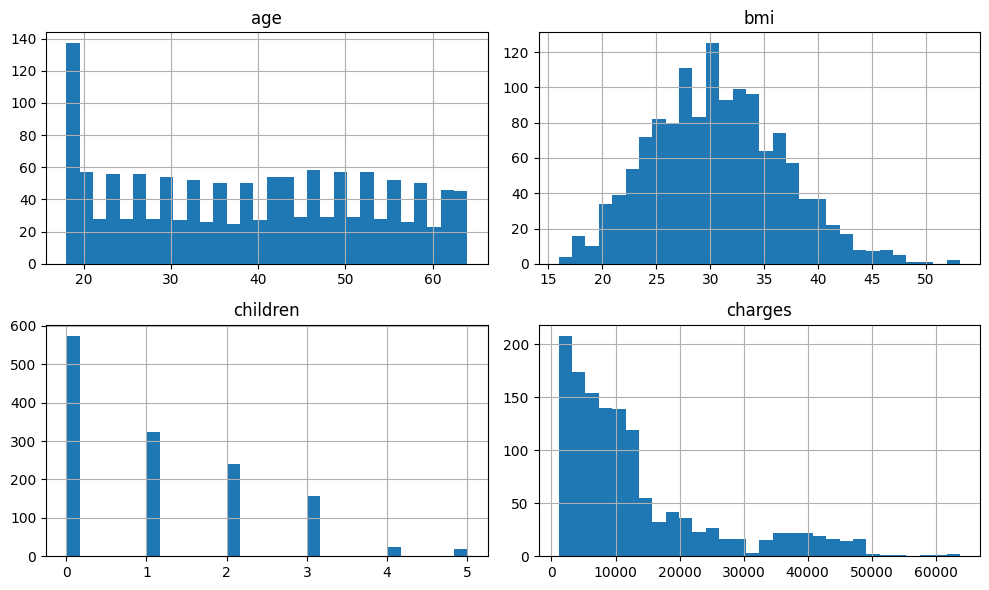

In [14]:
# numerical distributions
numeric_cols = ["age", "bmi", "children", "charges"]

df[numeric_cols].hist(bins=30, figsize=(10,6))
plt.tight_layout()
plt.show()

### Categorical Distributions
- Sex relatively balanced
- A lot fewer smokers than non-smokers
- Region fairly balanced across the four regions

sex
male      676
female    662
Name: count, dtype: int64


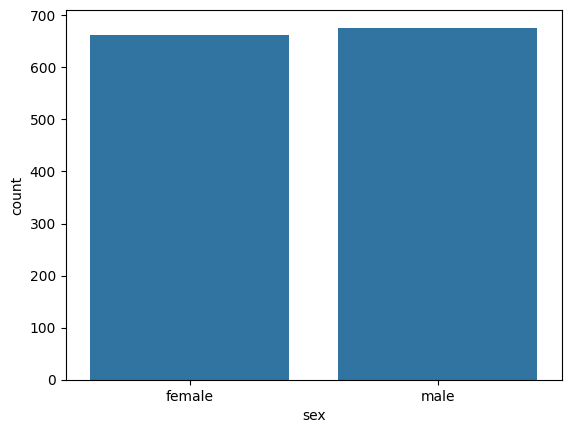

smoker
no     1064
yes     274
Name: count, dtype: int64


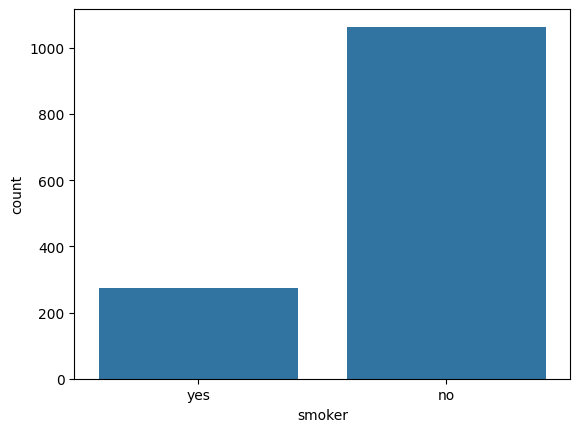

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


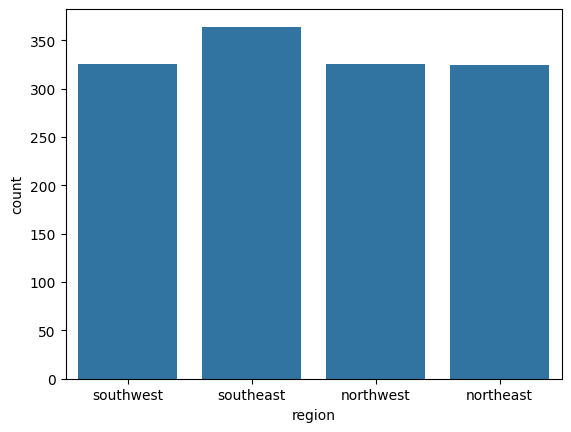

In [13]:
# categorical distributions
for col in ["sex", "smoker", "region"]:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.show()

### Feature Correlations
- Being a smoker has a very strong positive correlation with charges (0.79).
- Age (0.30) and BMI (0.20) also show positive correlations with charges, but but the relationships are much weaker.
- Most other features show weak/negligible correlations with charges, and correlations between other features are weak as well.
- Based on these correlations, we expect the PDP and ALE plots to show smoker status as the most influential feature, followed by age and BMI. Other features should have minimal effect on the predictions.

In [19]:
# preprocessing
# ChatGPT 5.0 used to generate preprocessing steps in three lines below on 9/27/25
df_encoded = pd.get_dummies(df, drop_first=True) # one-hot encode categorical features
X = df_encoded.drop("charges", axis=1) # features
y = df_encoded["charges"] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

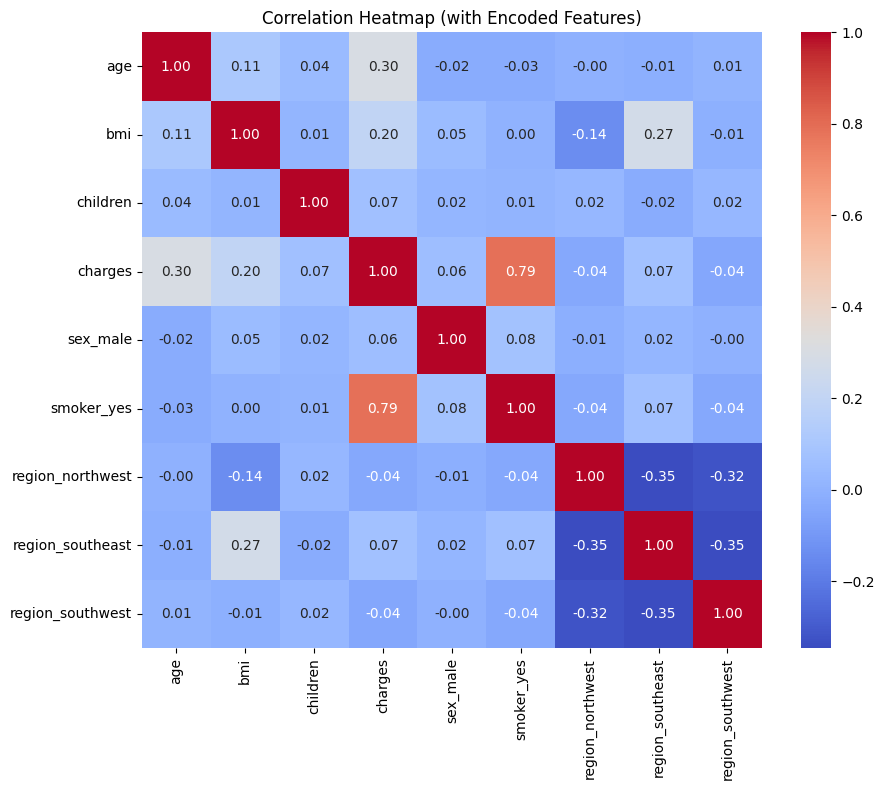

In [23]:
corr = df_encoded.corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap (with Encoded Features)")
plt.show()


In [24]:
# train model
model = xgb.XGBRegressor(random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# ICE Plots 🧊

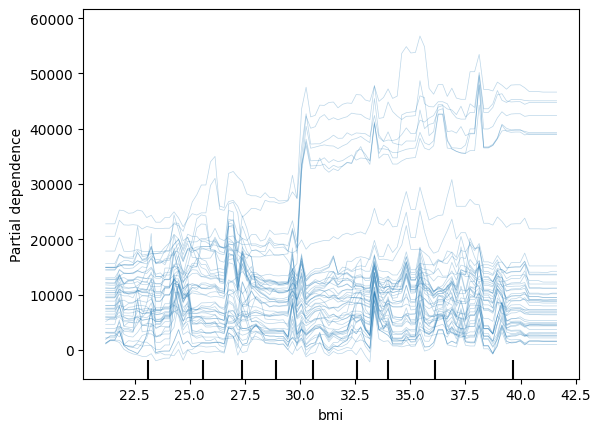

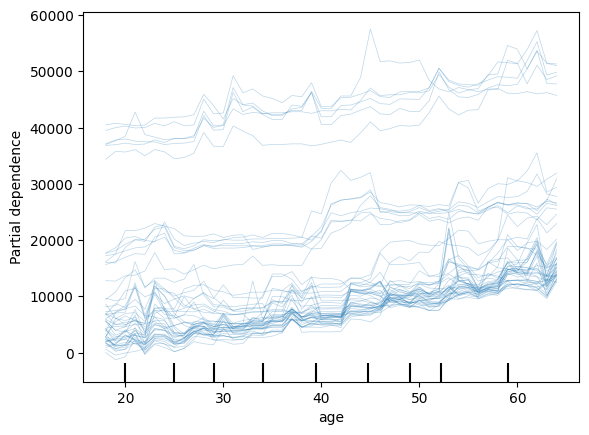

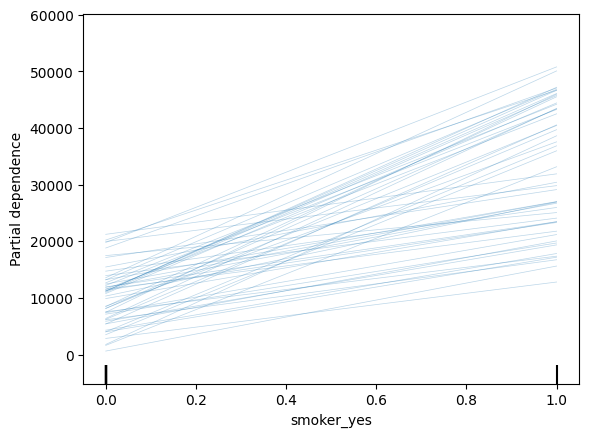

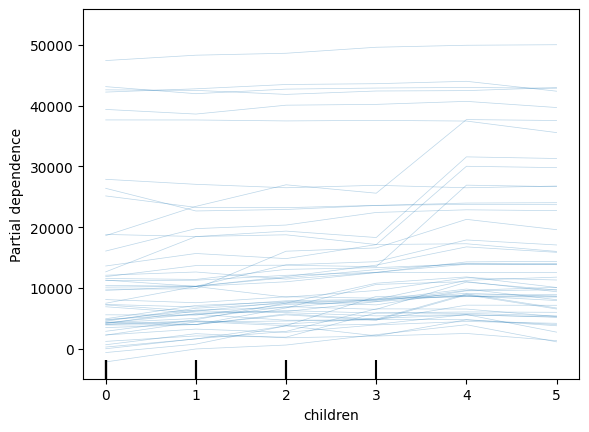

In [40]:
PartialDependenceDisplay.from_estimator(model, X_test, ["bmi"], kind="individual", subsample=50)
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["age"], kind="individual", subsample=50)
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["smoker_yes"], kind="individual", subsample=50)
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["children"], kind="individual", subsample=50)
plt.show()

# Partial Dependence Plots (PDP) 📈

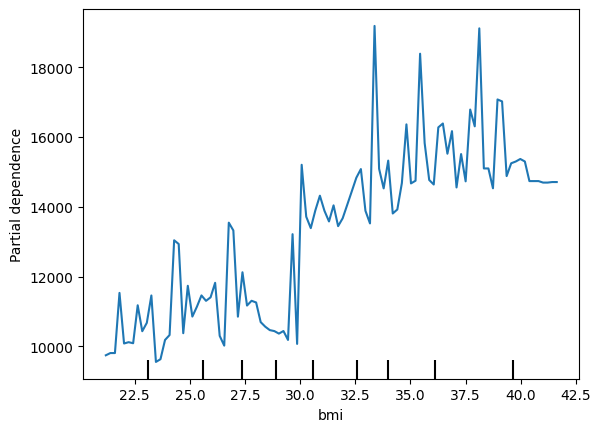

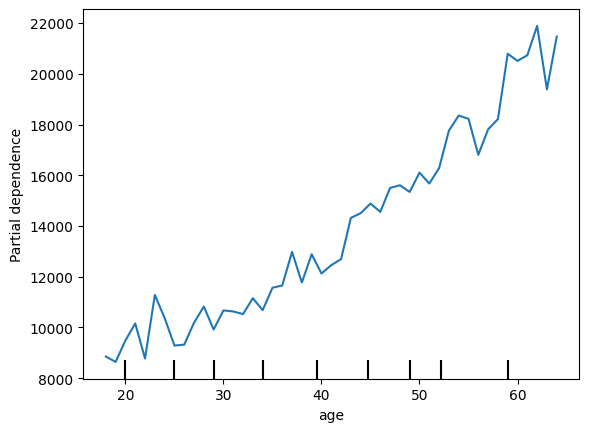

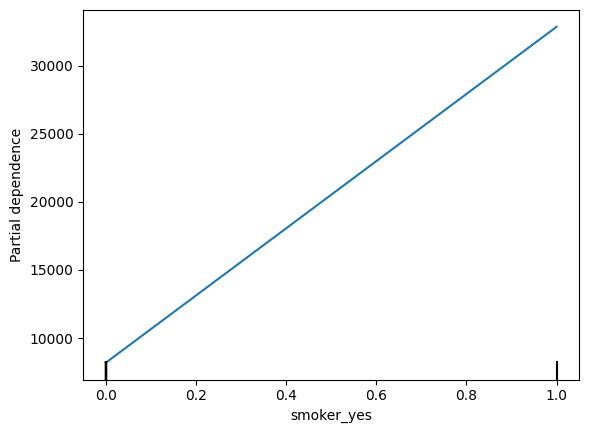

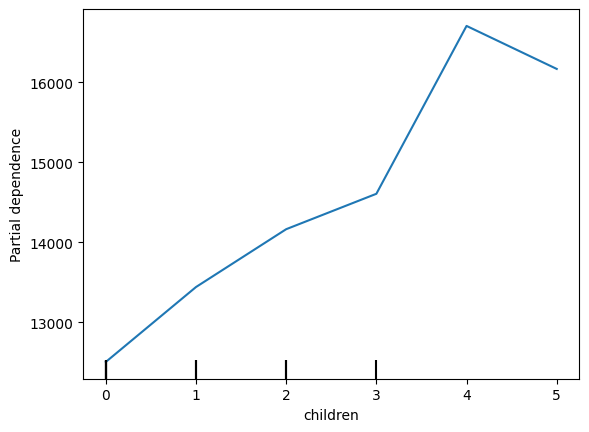

In [41]:
# PDP / global avg only
PartialDependenceDisplay.from_estimator(model, X_test, ["bmi"], kind="average")
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["age"], kind="average")
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["smoker_yes"], kind="average")
plt.show()
PartialDependenceDisplay.from_estimator(model, X_test, ["children"], kind="average")
plt.show()

# Accumulated Local Effects Plots (ALE) 📉

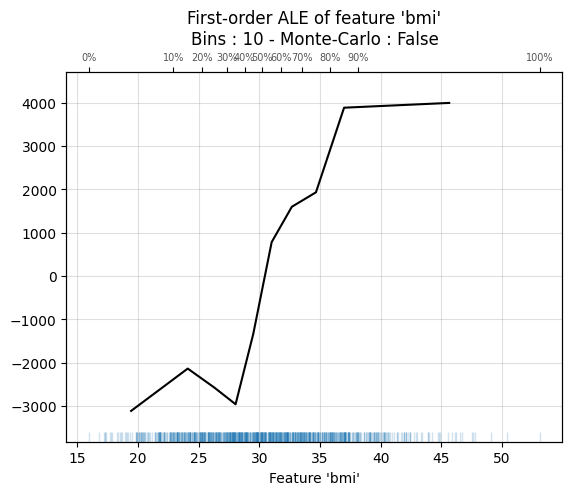

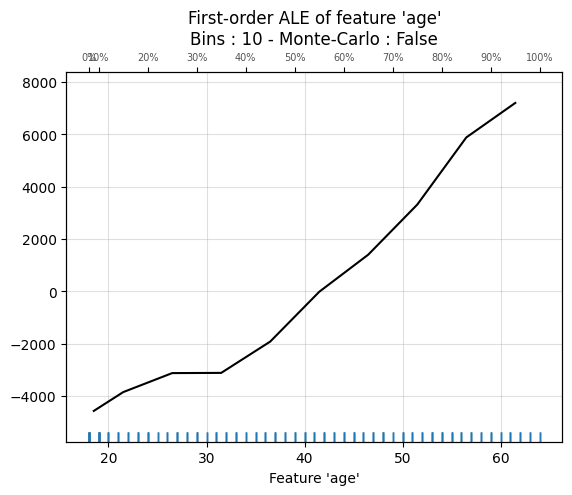

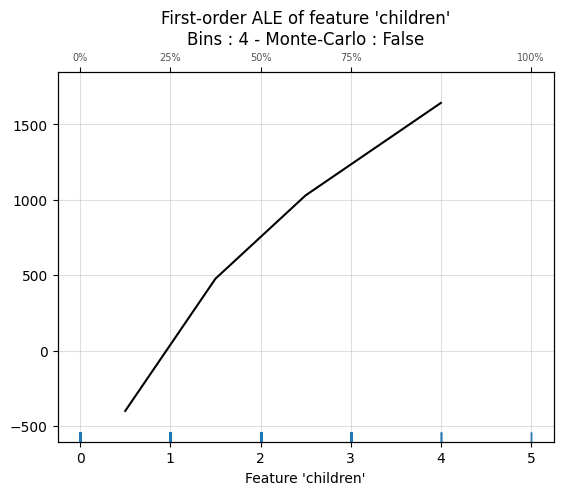

<Axes: title={'center': "First-order ALE of feature 'children'\nBins : 4 - Monte-Carlo : False"}, xlabel="Feature 'children'">

In [54]:
ale_plot(model, X_train, "bmi")
ale_plot(model, X_train, "age")
ale_plot(model, X_train, "children")

# Discussion

**BMI:**
- ICE: For individuals with higher predicted charges already (likely smokers), predictions rise sharply once BMI > 30. But for others, predictions stay relatively flat even as BMI increases. Although BMI and smoker are not correlated in the data (0.00), this heterogeneity in ICE suggests a possible interaction effect, likely between BMI and smoker status: changing BMI has a greater effect on costs for smokers compared to non-smokers.
- PDP: On average, predicted charges increase sharply when BMI passes threshold of 30. Line is jagged, likely reflecting noise and interactions.
- ALE: Same threshold effect at BMI of 30, but line is smoother. More stable than PDP because it is based on local distributions and avoids unrealistic BMI values in instances.

**Age:**
- ICE & PDP: Both show a clear linear increase in charges with age. There is very little heterogeneity.
- ALE: Also shows smooth gradual increase.
These results make sense and are consistent among the methods, as older individuals tend to have higher health insurance costs in a linear relationship.

**Smoker Status:**
- ICE: Every individual's cost prediction jumps up when switch from non-smoker to smoker, showing a strong, universal effect.
- PDP: Positively increasing line from 0 to 1, showing a clear interpretation that smokers consistently have higher charges.
- ALE: Problem because not designed for binary features (better for continuous features).

**Children:**
- Number of children has a weak effect on charges. ICE, PDP, and ALE show slight increases for some individuals with more children, but the effect is small (looking at the y axis scale) compared to smoking, age, and BMI.
- We expect similar results for other features weakly correlated with charges.

**ALE vs. PDP:**
- ALE gives smoother, more reliable curves when features are continuous. PDP can be jagged if correlations or interactions exist.
- In this dataset, correlations between features are relatively weak, so insights from PDP and ALE are similar for the most part--the main benefit of ALE here is in producing smoother curves.
- For datasets with stronger correlations, ALE would be particularly useful, as PDP may create unrealistic feature instances.

Overall, smoking status was the dominant predictor of medical insurance costs, followed by age and BMI. ICE revelaed important interactions between BMI and smoking status, while PDP and ALE provided complementary global explanations of feature importance.